<div class="alert alert-info">

<h3>Задание (выполнять в отдельном файле)</h3>
<p></p>
Рассмотрим задачу оценки стоимости недвижимости California housing.

<ol>
    <li>Разбейте выборку на обучение и контроль в соотношении 4:1. Сформируйте Dataset и Dataloader. Для обучения укажите размер мини-батча равным 32.</li>
    <li>Сформируйте архитектуру нейронной сети, указанную на рисунке. Выбор слоя нормализации реализуйте через ModuleDict. Будем рассматривать три возможных варианта:
        <ul>
            <li>отсутствие слоя нормализации;</li>
            <li>батч-нормализация;</li>
            <li>нормализация слоя.</li>
        </ul>
        В случае, если нормализация не используется, можно указать слой-заглушку nn.Identity().
        </li>
    <li>Обучите каждую из архитектур 50 эпох. Оптимизатор &ndash; Adam, шаг обучения &ndash; 0.001, функция потерь &ndash; nn.MSELoss(). Сохраняйте значение функции потерь на каждой эпохе (создать переменную losses_history = [] перед обучением, после завершения эпохи losses_history.append(losses)).</li>
    <li>Отобразите на одном графике полученный список функций потерь для каждой из архитектур.</li>
</ol>

<p></p>
Ответьте на вопросы:
<ul>
    <li>Как нормализация влияет на процесс обучения?</li>
    <li>Попробуйте указать размер мини-батча равным 3 и обучить архитектуры с нормализацией. Что произойдет при использовании батч-нормализации и нормализация слоя?</li>
    <li>Какой из способов нормализации будет более чувствителен к выбросам в данных и почему?</li>
</ul>  

</div>

In [23]:
from sklearn.datasets import fetch_california_housing

In [24]:
data = fetch_california_housing()
X = data.data
y = data.target

In [25]:
data.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [26]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
%matplotlib inline

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [28]:
class NeuralNet(nn.Module):
    def __init__(self, norm_type='none'):
        super(NeuralNet, self).__init__()
        
        self.linear1 = nn.Linear(in_features=8, out_features=64)
        self.linear2 = nn.Linear(in_features=64, out_features=64)
        self.output_layer = nn.Linear(in_features=64, out_features=1)
        self.activation = nn.Tanh()
        
        self.norm_layers = nn.ModuleDict({
            'none': nn.Identity(),
            'batch': nn.BatchNorm1d(num_features=64),
            'layer': nn.LayerNorm(normalized_shape=64)
        })
        
        self.norm1 = self.norm_layers[norm_type]
        self.norm2 = self.norm_layers[norm_type]
        
    def forward(self, x):
        x = self.activation(self.norm1(self.linear1(x)))
        x = self.activation(self.norm2(self.linear2(x)))
        x = self.output_layer(x)
        return x

In [29]:
def train_model(norm_type, n_epochs=50, lr=0.001, batch_size=32):
    torch.manual_seed(42)
    np.random.seed(42)
    
    dataset = TensorDataset(X_train_tensor, y_train_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    model = NeuralNet(norm_type=norm_type)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    losses_history = []
    
    for epoch in range(n_epochs):
        losses = 0
        model.train()
        for x_batch, y_batch in loader:
            optimizer.zero_grad()
            pred = model(x_batch)
            loss = criterion(pred, y_batch)
            losses += loss.item() / len(loader)
            loss.backward()
            optimizer.step()
        
        losses_history.append(losses)
    
    return losses_history

In [30]:
print("Обучение без нормализации")
losses_history_nonorm = train_model(norm_type='none')
losses_history_nonorm[-5:]

Обучение без нормализации


[0.5672239746118701,
 0.5878034421466585,
 0.5682474787729657,
 0.5574363443798332,
 0.5633225256158396]

In [31]:
print("Обучение с батч-нормализацией")
losses_history_batch = train_model(norm_type='batch')
losses_history_batch[-5:]

Обучение с батч-нормализацией


[0.4300921358197001,
 0.42303072717473933,
 0.4191012625373148,
 0.4123336766781506,
 0.42020286187933814]

In [32]:
print("Обучение с нормализацией слоя")
losses_history_layer = train_model(norm_type='layer')
losses_history_layer[-5:]

Обучение с нормализацией слоя


[0.4688047998000023,
 0.4712538160094921,
 0.465463027733472,
 0.4628434804982918,
 0.4677563701258154]

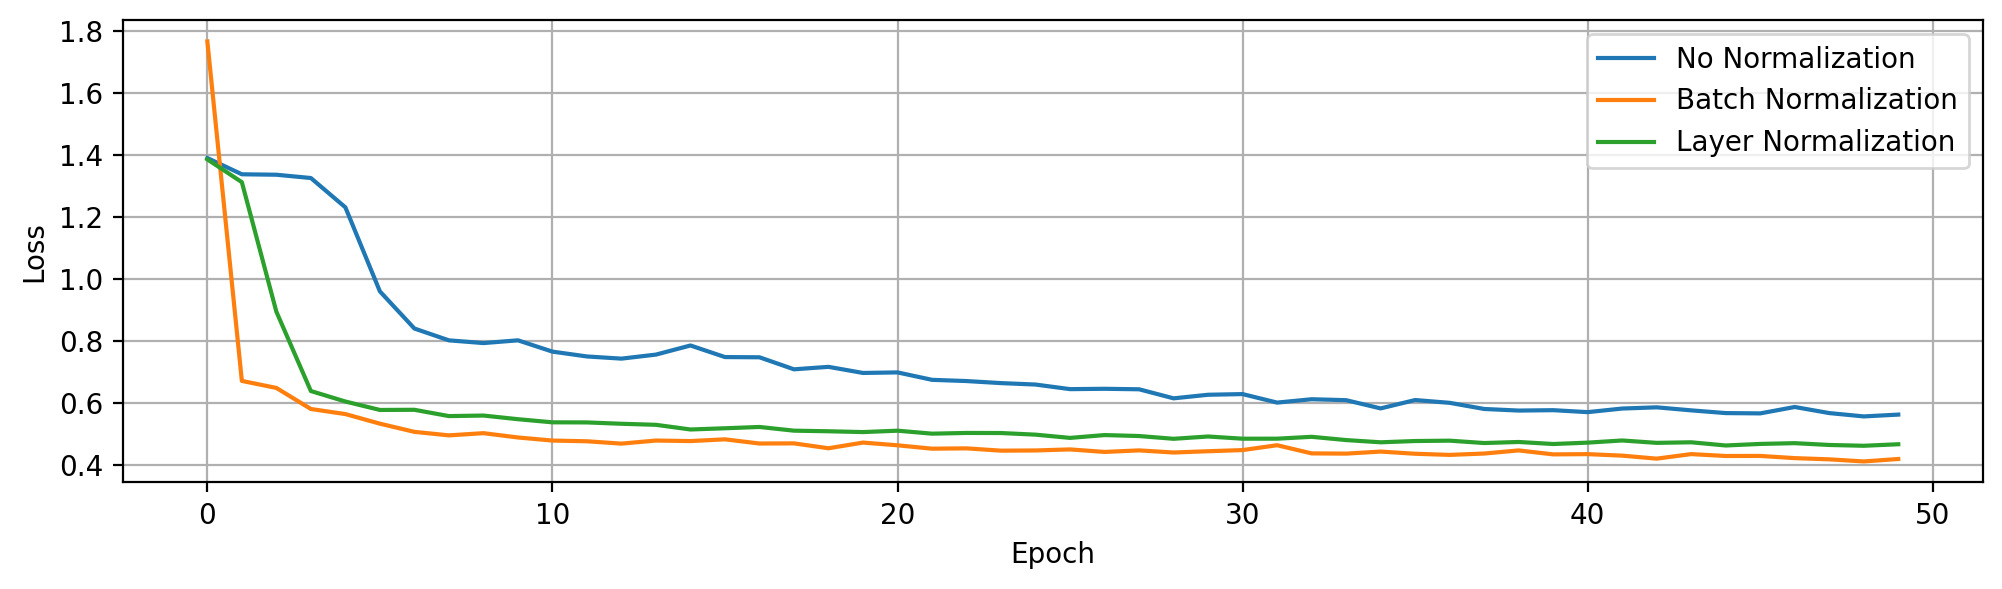

In [33]:
plt.figure(figsize=(12,3), dpi=200)
plt.plot(losses_history_nonorm, label='No Normalization')
plt.plot(losses_history_batch, label='Batch Normalization')
plt.plot(losses_history_layer, label='Layer Normalization')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Как нормализация влияет на процесс обучения?
Нормализация ускоряет сходимость процесса обучения. Модели с нормализацией быстрее достигают низких значений функции потерь.

Что произойдет при размере мини-батча равным 3?

In [34]:
print("Обучение с батч-нормализацией")
losses_history_batch_3 = train_model(norm_type='batch', batch_size=3)
losses_history_batch_3[-5:]

print("Обучение с нормализацией слоя")
losses_history_layer_3 = train_model(norm_type='layer', batch_size=3)
losses_history_layer_3[-5:]

Обучение с батч-нормализацией
Обучение с нормализацией слоя


[0.4611454169630688,
 0.4600458137253327,
 0.4602366242916319,
 0.4573573457809309,
 0.4575123778110944]

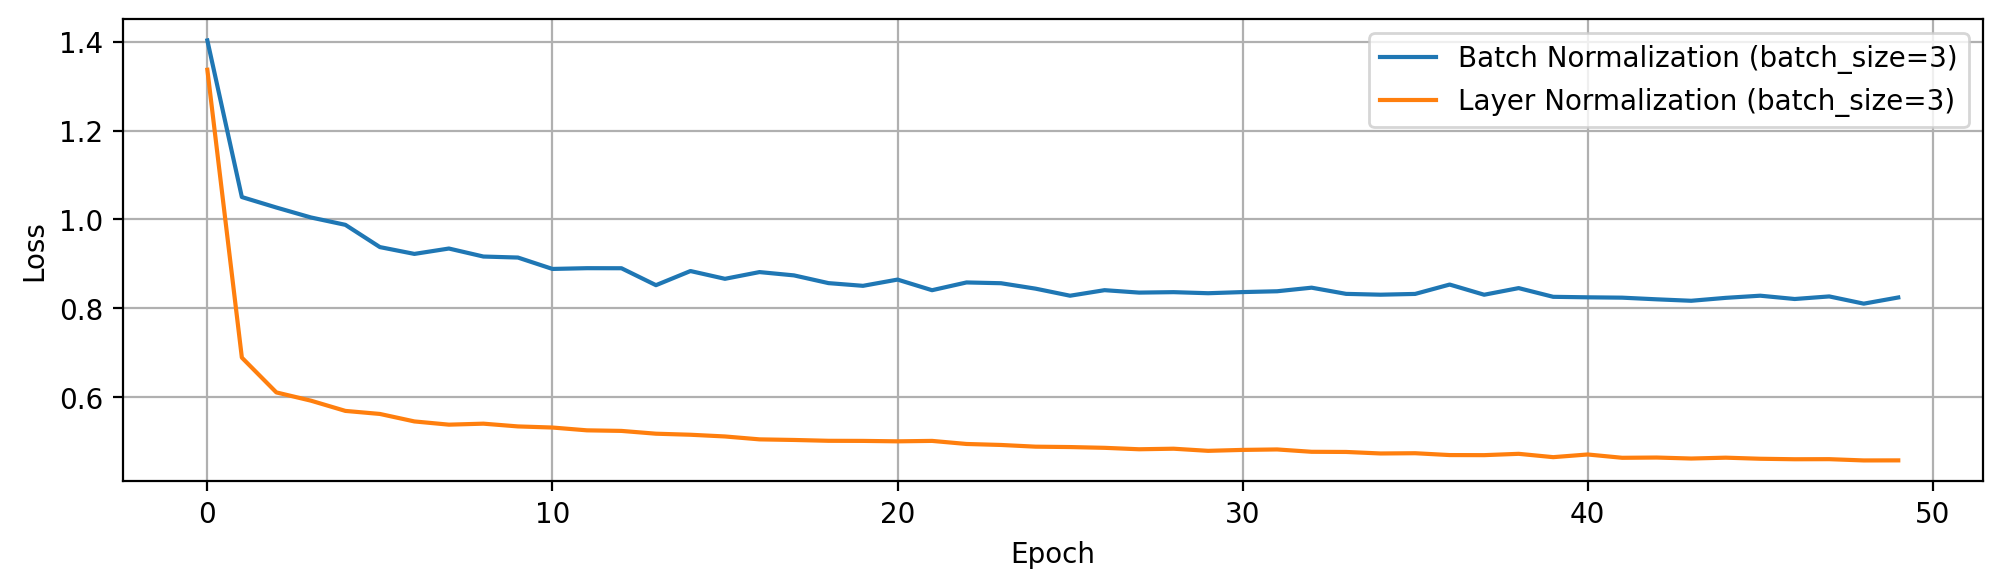

In [35]:
plt.figure(figsize=(12,3), dpi=200)
plt.plot(losses_history_batch_3, label='Batch Normalization (batch_size=3)')
plt.plot(losses_history_layer_3, label='Layer Normalization (batch_size=3)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Какой из способов нормализации более чувствителен к выбросам? Батч-нормализация более чувствительна к выбросам.